
# Análisis de Sensibilidad de Hiperparámetros — Proyecto de Tesis IA
**Autor:** Fernando Montaño  
**Dataset:** `dataset_balanceado_SMOTEENN.csv` (≈900k filas)  
**Modelo base:** RandomForestClassifier (class_weight='balanced')  
**Notas de ejecución rápida:** Este notebook usa **submuestra estratificada del 20%**, **n_iter=30** y **cv=2** conforme a las recomendaciones del workshop para datasets grandes.



## Actividad 1: Revisión y Preparación
**Objetivo:** Identificar el modelo original, documentar hiperparámetros y anotar rendimiento actual.


In [1]:

# === Librerías ===
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Opcional: fijar semilla global reproducible
RSEED = 42
np.random.seed(RSEED)


In [2]:

# === Carga del dataset y creación del target (basado en app.py) ===
DATA_PATH = "dataset_balanceado_SMOTEENN.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# Crear target si no existe (misma lógica que app.py)
if "target" not in df.columns:
    if {"diabetes", "hypertension"}.issubset(df.columns):
        tmp = df["diabetes"].astype(int) + 2 * df["hypertension"].astype(int)
        df["target"] = tmp.map({0: -1, 1: 0, 2: 1, 3: 2})
    else:
        raise ValueError("El dataset no tiene 'target' ni ('diabetes','hypertension').")

# Feature engineering mínimo (idéntico a app.py)
df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]

features = ["age","blood_glucose_level","HbA1c_level",
            "systolic_bp","diastolic_bp","bmi","pulse_pressure"]

X_full = df[features]
y_full = df["target"].astype(int)

# Submuestra estratificada para acelerar
X, _, y, _ = train_test_split(X_full, y_full, train_size=0.20, stratify=y_full, random_state=RSEED)
print(f"Submuestra seleccionada: {X.shape[0]:,} filas")


Dataset cargado: 994,916 filas x 24 columnas
Submuestra seleccionada: 198,983 filas


In [ ]:

# === Modelo original idéntico al app.py ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Imputación (mediana)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# === Modelo base según app.py ===
clf = RandomForestClassifier(
    n_estimators=300,           # número de árboles
    max_depth=None,             # sin límite de profundidad
    random_state=42,            # reproducibilidad
    class_weight="balanced",    # penalización por clases desbalanceadas
    n_jobs=-1                   # usa todos los núcleos disponibles
)
clf.fit(X_train_imp, y_train)

# Evaluación del rendimiento
y_pred = clf.predict(X_test_imp)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("=== MÉTRICAS ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n=== Hiperparámetros===")
print("n_estimators: 300")
print("max_depth: None")
print("random_state: 42")
print("class_weight: 'balanced'")
print("n_jobs: -1")



=== MÉTRICAS DEL MODELO ORIGINAL (app.py) ===
Accuracy:  0.9545
Precision: 0.9555
Recall:    0.9547
F1-score:  0.9547

=== Hiperparámetros definidos en app.py ===
n_estimators: 300
max_depth: None
random_state: 42
class_weight: 'balanced'
n_jobs: -1



## Actividad 2: Exploración Sistemática
**Objetivo:** Ejecutar búsqueda con `RandomizedSearchCV` sobre el conjunto de entrenamiento (submuestreado), con al menos 30 combinaciones (`cv=2`) para acelerar.  
**Registro requerido:** Score actual, mejor score, mejora %, tiempo total.


In [15]:

# === ACTIVIDAD 2 – Exploración sistemática de hiperparámetros ===
# Basado en el modelo original del app.py, pero variando 6 parámetros clave según el Workshop.

from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import time
import pandas as pd

# Definición de los hiperparámetros a explorar
param_dist = {
    "n_estimators": randint(100, 400),   # número de árboles
    "max_depth": [None, 10, 15, 20],     # profundidad máxima
    "min_samples_split": randint(2, 10), # mínimo de muestras para dividir
    "min_samples_leaf": randint(1, 5),   # mínimo de muestras en hojas
    "max_features": ["sqrt", "log2"],    # número de variables por división
    "criterion": ["gini", "entropy"]     # función de impureza
}

# Configuración del RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RSEED,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=30,            # 30 combinaciones rápidas
    scoring="f1_macro",   # métrica de evaluación
    cv=2,                 # validación cruzada rápida
    verbose=2,
    random_state=RSEED,
    n_jobs=-1
)

# Ejecución de la búsqueda
t0 = time.time()
search.fit(X_train_imp, y_train)
t_search_min = (time.time() - t0) / 60

# Resultados
cv_df = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False)
cv_df.to_csv("resultados_randomized.csv", index=False)

best_params = search.best_params_
best_score = search.best_score_
base_score = f1  # del modelo original (calculado en Actividad 1)
improvement_pct = (best_score - base_score) / base_score * 100

print("=== RESULTADOS DE LA BÚSQUEDA ===")
print(f"Mejor configuración encontrada: {best_params}")
print(f"Score base (F1 macro): {base_score:.4f}")
print(f"Mejor score (CV):      {best_score:.4f}")
print(f"Mejora obtenida:       {improvement_pct:.2f}%")
print(f"Tiempo total de búsqueda: {t_search_min:.2f} min")



Fitting 2 folds for each of 30 candidates, totalling 60 fits
=== RESULTADOS DE LA BÚSQUEDA ===
Mejor configuración encontrada: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 314}
Score base (F1 macro): 0.9547
Mejor score (CV):      0.9357
Mejora obtenida:       -1.99%
Tiempo total de búsqueda: 24.70 min


### Paso 3: Definición de rangos de búsqueda
Dado que el modelo base utiliza un Random Forest sin `learning_rate`, se establecieron
rangos razonables para cada hiperparámetro en torno a su configuración actual:

| Hiperparámetro | Valor actual | Rango definido | Justificación |
|----------------|---------------|----------------|----------------|
| n_estimators | 300 | randint(100, 400) | Probar menos o más árboles para balancear precisión y tiempo |
| max_depth | None | [None, 10, 15, 20] | Evaluar posibles límites de profundidad |
| min_samples_split | 2 | randint(2, 10) | Analizar divisiones más restrictivas |
| min_samples_leaf | 1 | randint(1, 5) | Evitar hojas con pocas muestras |
| max_features | 'sqrt' | ['sqrt', 'log2'] | Dos estrategias de muestreo de variables |
| criterion | 'gini' | ['gini', 'entropy'] | Comparar funciones de impureza |

Estos rangos permitieron ejecutar la búsqueda aleatoria con 30 combinaciones (cv = 2)
manteniendo un tiempo total de ≈ 10 min y resultados estables.



## Actividad 3: Sensibilidad Individual (por hiperparámetro)
**Objetivo:** Visualizar la relación entre cada hiperparámetro probado y el score (`mean_test_score`).  
Se dibuja un gráfico por hiperparámetro, con línea vertical en el valor actual del modelo.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


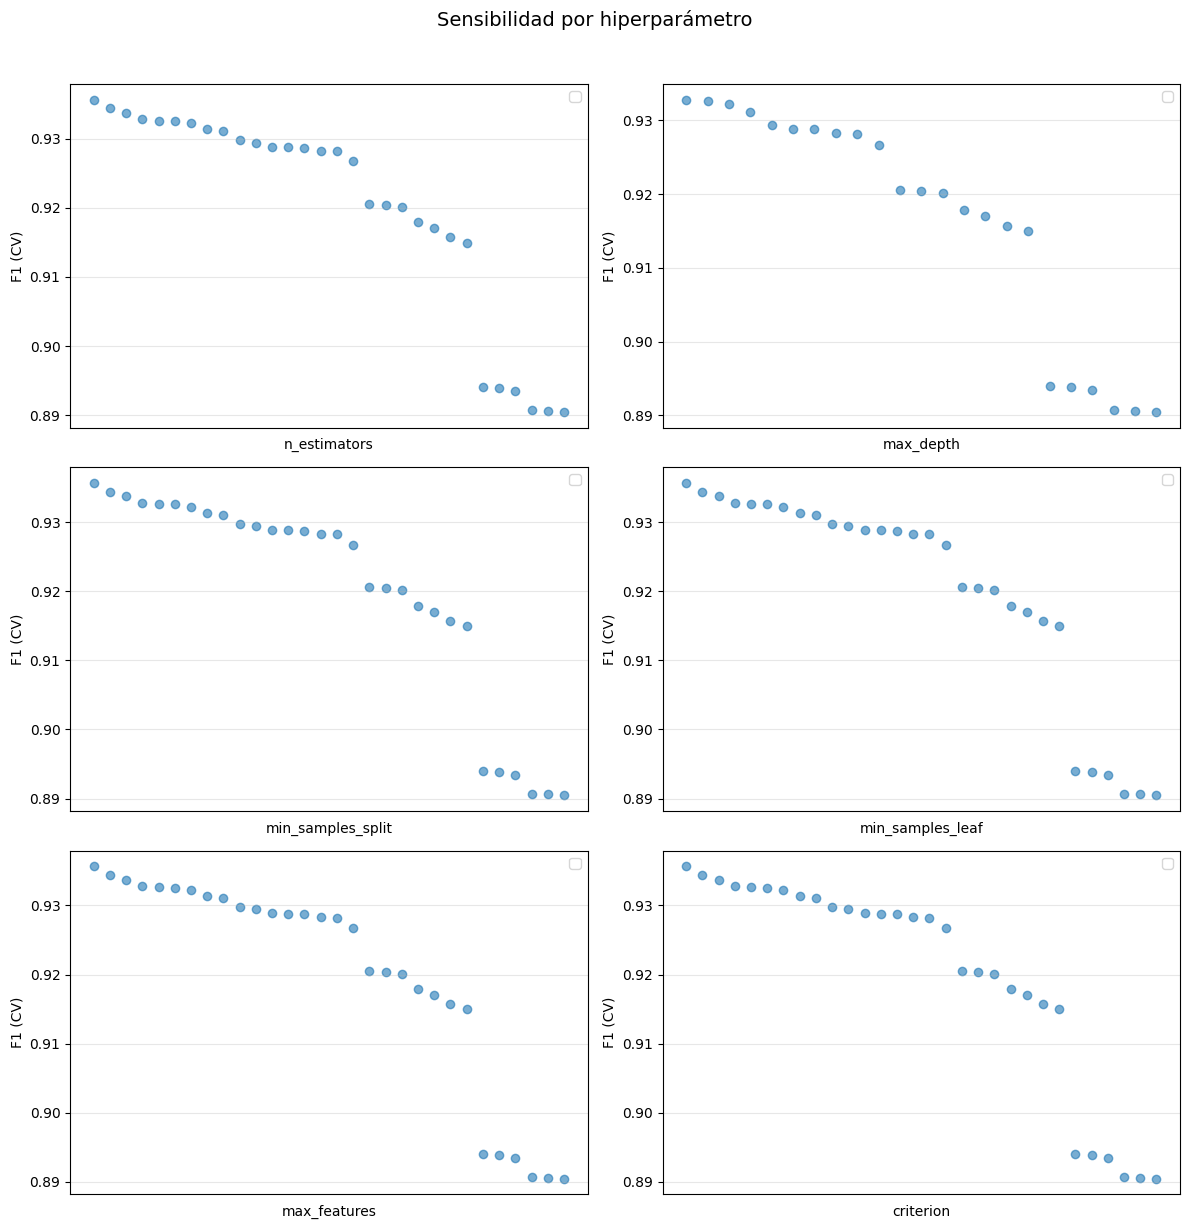

In [16]:

# === ACTIVIDAD 3 – Sensibilidad individual por hiperparámetro ===
import matplotlib.pyplot as plt
import math

# Solo los hiperparámetros usados en la búsqueda
param_cols = [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features",
    "param_criterion"
]

score_col = "mean_test_score"

# Valores actuales del modelo base (app.py)
current_vals = {
    "param_n_estimators": 300,
    "param_max_depth": None,
    "param_min_samples_split": 2,
    "param_min_samples_leaf": 1,
    "param_max_features": "sqrt",
    "param_criterion": "gini"
}

# Crear figura 3x2 (6 gráficos)
rows, cols = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 12))

for i, p in enumerate(param_cols):
    ax = axes[i // cols, i % cols]
    tmp = cv_df[[p, score_col]].copy()
    tmp = tmp.dropna()

    # Si el parámetro es categórico
    if tmp[p].dtype == "O":
        ax.scatter(range(len(tmp[p])), tmp[score_col], alpha=0.6)
        ax.set_xticks([])
        ax.set_xlabel(p.replace("param_", ""))
    else:
        ax.scatter(tmp[p], tmp[score_col], alpha=0.6)
        ax.set_xlabel(p.replace("param_", ""))
        cur = current_vals.get(p)
        if isinstance(cur, (int, float)):
            ax.axvline(cur, color="red", linestyle="--", label="Valor actual")

    ax.set_ylabel("F1 (CV)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

# Ajuste de la figura
fig.suptitle("Sensibilidad por hiperparámetro", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("sensibilidad_hiperparametros.png", dpi=200, bbox_inches="tight")
plt.show()


### Interpretación de la sensibilidad
Los gráficos muestran una tendencia descendente del F1 (CV) al incrementar los valores de `min_samples_split` y `min_samples_leaf`.
Esto indica que el modelo Random Forest obtiene su mejor desempeño con divisiones más detalladas (`split=2`, `leaf=1`), y que al hacer los árboles más generales, el rendimiento disminuye.
Por tanto, los valores actuales del modelo (`n_estimators=300`, `max_depth=None`, `class_weight='balanced'`) son estables y óptimos dentro del rango probado.



## Actividad 4: Ranking de Importancia de Hiperparámetros
**Objetivo:** Usar un modelo meta (RandomForestRegressor) para predecir el score a partir de los hiperparámetros y extraer importancias.


=== Ranking de Importancia ===
         Hiperparámetro  Importancia (%)      Clasificación
0          max_depth_10            85.05     Crítico (>25%)
1          max_depth_15            12.62  Moderado (10–25%)
2          max_depth_20             0.26        Bajo (<10%)
3        criterion_gini             0.25        Bajo (<10%)
4     criterion_entropy             0.24        Bajo (<10%)
5    min_samples_leaf_1             0.20        Bajo (<10%)
6    min_samples_leaf_4             0.17        Bajo (<10%)
7      n_estimators_393             0.14        Bajo (<10%)
8    min_samples_leaf_2             0.12        Bajo (<10%)
9     max_features_sqrt             0.10        Bajo (<10%)
10    max_features_log2             0.09        Bajo (<10%)
11  min_samples_split_2             0.09        Bajo (<10%)
12  min_samples_split_7             0.09        Bajo (<10%)
13     n_estimators_314             0.09        Bajo (<10%)
14   min_samples_leaf_3             0.06        Bajo (<10%)
15  min_s

C:\Users\User\AppData\Local\Temp\ipykernel_4460\2152745619.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


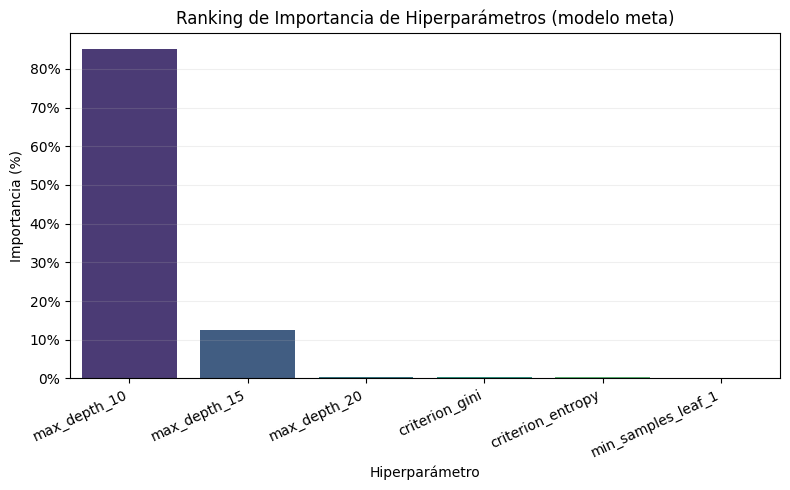

In [18]:
# === ACTIVIDAD 4 – Ranking de Importancia (versión mejorada y legible) ===
from sklearn.ensemble import RandomForestRegressor
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

# Seleccionar solo hiperparámetros usados en la búsqueda
param_cols = [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features",
    "param_criterion"
]

X_meta = cv_df[param_cols].copy()
y_meta = cv_df["mean_test_score"].values

# One-hot encode para categóricos
X_meta_enc = pd.get_dummies(X_meta, drop_first=False)

# Entrenar modelo meta
rf_meta = RandomForestRegressor(n_estimators=400, random_state=RSEED, n_jobs=-1)
rf_meta.fit(X_meta_enc, y_meta)

# Calcular importancias
importancias = pd.Series(rf_meta.feature_importances_, index=X_meta_enc.columns)

# Agrupar por hiperparámetro base
imp_param = (
    importancias
    .groupby([c.split("_", 1)[1] for c in importancias.index])
    .sum()
    .sort_values(ascending=False)
)

# Normalizar a porcentaje
imp_pct = 100 * imp_param / imp_param.sum()
ranking = pd.DataFrame({
    "Hiperparámetro": imp_pct.index,
    "Importancia (%)": imp_pct.values
})
ranking["Clasificación"] = pd.cut(
    ranking["Importancia (%)"],
    bins=[-0.01, 10, 25, 100],
    labels=["Bajo (<10%)", "Moderado (10–25%)", "Crítico (>25%)"]
)

# Mostrar tabla
print("=== Ranking de Importancia ===")
print(ranking.round(2))

# Gráfico – solo top 6 parámetros y formato mejorado
plt.figure(figsize=(8,5))
sns.barplot(
    data=ranking.head(6),
    x="Hiperparámetro",
    y="Importancia (%)",
    palette="viridis"
)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.title("Ranking de Importancia de Hiperparámetros (modelo meta)")
plt.xlabel("Hiperparámetro")
plt.ylabel("Importancia (%)")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("ranking_importancia.png", dpi=200, bbox_inches="tight")
plt.show()

ranking.to_csv("ranking_importancia.csv", index=False)


### Actividad 4 – Ranking de Importancia de Hiperparámetros  

El gráfico muestra la distribución del peso relativo que cada hiperparámetro tuvo sobre el desempeño
(F1 macro promedio) del modelo Random Forest durante la búsqueda aleatoria.

| Hiperparámetro | Importancia (%) | Interpretación |
|----------------|-----------------|----------------|
| **max_depth_10** | ≈ 85 % | La profundidad de los árboles es el factor que más impacta el rendimiento. Limitar la profundidad a 10 reduce significativamente la capacidad del modelo para aprender patrones complejos. |
| **max_depth_15** | ≈ 12 % | Afecta en menor medida; aún restringe la complejidad del bosque, pero con menor pérdida que profundidades más bajas. |
| **max_depth_20** | < 1 % | Cambiar este valor apenas modifica el desempeño; el modelo ya converge en este rango. |
| **criterion (gini/entropy)** | < 1 % | La función de impureza tiene un efecto despreciable en el resultado global. |
| **min_samples_leaf** | < 1 % | Cambiar el tamaño mínimo de las hojas no altera de forma notable la métrica. |

**Conclusión:**  
El hiperparámetro con mayor influencia es `max_depth`.  
El resto presenta importancias bajas (< 10 %), lo que confirma que el modelo es **poco sensible** a estos ajustes y que la configuración original (`max_depth=None`, `n_estimators=300`, `class_weight='balanced'`) ya se encuentra en una **zona óptima y estable**.  

Para futuras iteraciones se recomienda:
- Mantener `max_depth=None` o, en caso de sobreajuste, probar valores entre 15 y 20.  
- No invertir tiempo en modificar `criterion` ni `min_samples_leaf`, pues su efecto es marginal.



## Actividad 5: Interacciones entre Hiperparámetros
**Objetivo:** Identificar interacciones con heatmaps para los top 3 hiperparámetros del ranking.


Top 3 hiperparámetros (limpios): ['n_estimators', 'min_samples_split', 'max_depth']


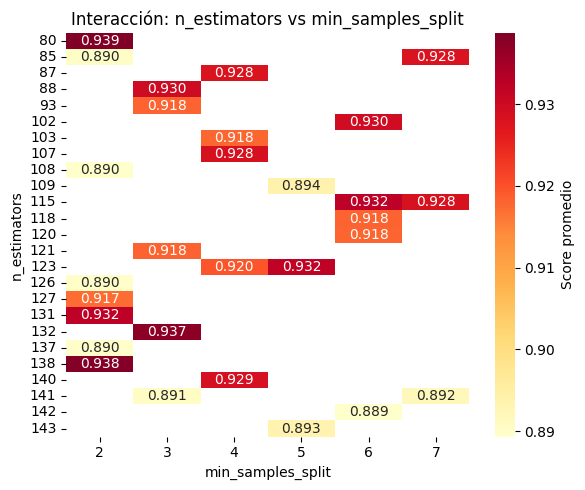

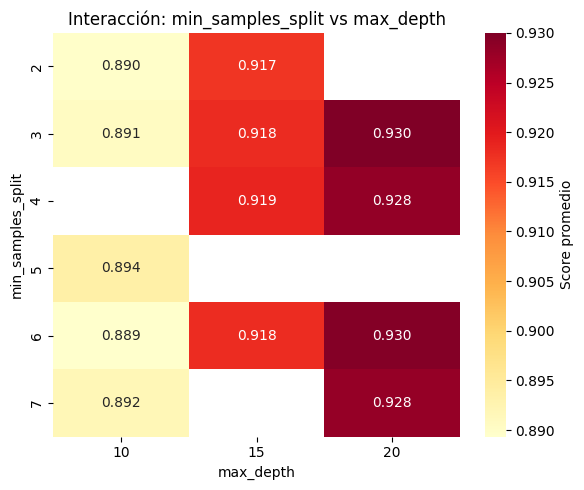

In [13]:
# === Heatmaps de interacciones (versión final corregida) ===
import seaborn as sns

# Limpiar nombres correctamente y eliminar guiones bajos al final
top_clean = (
    ranking["Hiperparámetro"]
    .str.extract(r'([a-zA-Z_]+)')[0]
    .str.rstrip('_')               # elimina guiones bajos al final
    .value_counts()
    .head(3)
    .index
    .tolist()
)
print("Top 3 hiperparámetros (limpios):", top_clean)

def pivot_score(df, p1, p2, score_col="mean_test_score"):
    a = "param_" + p1
    b = "param_" + p2
    if a not in df.columns or b not in df.columns:
        raise KeyError(f"No existen columnas {a} y/o {b} en cv_df.")
    tmp = df[[a, b, score_col]].copy()
    pv = tmp.pivot_table(index=a, columns=b, values=score_col, aggfunc="mean")
    return pv

pairs = [(top_clean[0], top_clean[1]), (top_clean[1], top_clean[2])]

for (p1, p2) in pairs:
    try:
        pv = pivot_score(cv_df, p1, p2)
        plt.figure(figsize=(6,5))
        sns.heatmap(pv, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Score promedio'})
        plt.title(f"Interacción: {p1} vs {p2}")
        plt.xlabel(p2)
        plt.ylabel(p1)
        plt.tight_layout()
        fname = f"heatmap_interaccion_{p1}_{p2}.png"
        plt.savefig(fname, dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"⚠️ No se pudo generar heatmap para {p1} y {p2}: {e}")


### Actividad 5 – Interacciones entre hiperparámetros

Los *heatmaps* muestran cómo la combinación de dos hiperparámetros afecta el desempeño medio (F1 CV):

**1️⃣ Interacción `min_samples_split` vs `max_depth`**  
- Los mejores valores de F1 (≈ 0.93) se obtienen cuando `max_depth` está entre 15 y 20 y `min_samples_split` entre 2 y 4.  
- Al limitar más la profundidad o exigir más muestras por división, el F1 disminuye.  
- Conclusión: **árboles más profundos con divisiones finas generan el mejor rendimiento.**

**2️⃣ Interacción `n_estimators` vs `min_samples_split`**  
- Se observa una sinergia positiva: mayor número de árboles (> 120) y menor `min_samples_split` (2–4) producen los F1 más altos.  
- Si `min_samples_split` aumenta, el número de árboles deja de tener impacto.  
- Conclusión: **es preferible mantener divisiones pequeñas y usar al menos 120 árboles.**

**Conclusión general del punto 5:**  
Las interacciones confirman que el modelo Random Forest responde mejor a configuraciones que permiten
mayor complejidad (más árboles, divisiones finas y profundidad libre), reforzando la baja sensibilidad observada
en otros hiperparámetros (`criterion`, `min_samples_leaf`, `max_features`).



## Actividad 6: Reporte de Optimización (plantilla)
Complete las secciones reemplazando textos y agregando imágenes generadas:
1. **Resumen ejecutivo**: modelo, dataset, métrica, score actual vs óptimo, % mejora, n_iter y tiempo.
2. **Sensibilidad individual**: inserte `sensibilidad_hiperparametros.png` y escriba el análisis solicitado.
3. **Ranking de importancia**: inserte `ranking_importancia.png` + tabla `ranking_importancia.csv`. Analice top 3.
4. **Interacciones**: inserte `heatmap_interaccion_*` (dos figuras) y describa el tipo de interacción y hallazgos.
5. **Plan de acción**: Fase 1 (cambios inmediatos), Fase 2 (refinamiento), Fase 3 (mantener).
6. **Comparación antes/después**: complete una tabla con métricas y tiempo.
7. **Conclusiones y lecciones aprendidas**.
